# LangGraph Intro

## Τι είναι το LangGraph;

Το **LangGraph** είναι μια βιβλιοθήκη για την κατασκευή **γράφων εκτέλεσης** (execution graphs) όπου κάθε κόμβος (node) είναι μια Python συνάρτηση που διαβάζει και γράφει σε ένα κοινό **state**.

Βασικές έννοιες:

| Έννοια | Ανάλογο | Ρόλος |
|---|---|---|
| **State** | Κοινή μνήμη | TypedDict που μοιράζονται όλοι οι κόμβοι |
| **Node** | Agent / βήμα | Python συνάρτηση `fn(state) -> dict` |
| **Edge** | Ροή | Πάντα πηγαίνει από A  B |
| **Conditional Edge** | Απόφαση | Η επόμενη κατεύθυνση εξαρτάται από το state |
| **END** | Τέλος | Ειδικό node που τερματίζει το γράφο |

```
         ┌──────────┐
  START  │          │
────────│ classifier│
         │          │
         └────┬─────┘
              │
       ┌──────┴──────┐
                    
  ┌─────────┐   ┌─────────┐
  │ branch A│   │ branch B│
  └────┬────┘   └────┬────┘
       │             │
       └──────┬──────┘
              
           [ END ]
```

Αυτό ακριβώς θα φτιάξετε στην εργασία σας: ένα γράφο με agents-nodes και conditional edges που αποφασίζουν πού πάει η ροή.


In [ ]:
! uv pip install -q langgraph


## Παράδειγμα 1: Ένα απλό γραμμικό pipeline

Το πιο απλό γράφο: A  B  END.
Κανένα branching, απλά αλυσίδα βημάτων.


In [8]:
from typing import TypedDict
from langgraph.graph import StateGraph, END

# Κάθε node διαβάζει από εδώ και επιστρέφει ένα dict με τα πεδία που άλλαξε.
class TextState(TypedDict):
    raw_text: str
    cleaned: str
    word_count: int

def clean(state: TextState) -> dict:
    text = state["raw_text"].strip().lower()
    print(f"[clean] '{state['raw_text']}'  '{text}'")
    return {"cleaned": text}

def count_words(state: TextState) -> dict:
    n = len(state["cleaned"].split())
    print(f"[count_words] {n} words")
    return {"word_count": n}

graph = StateGraph(TextState)

graph.add_node("clean", clean)
graph.add_node("count_words", count_words)

graph.set_entry_point("clean")       # πρώτο node
graph.add_edge("clean", "count_words")
graph.add_edge("count_words", END)

app = graph.compile()

result = app.invoke({"raw_text": "  Hello World from LangGraph  ", "cleaned": "", "word_count": 0})
print("\nFinal state:", result)


[clean] '  Hello World from LangGraph  '  'hello world from langgraph'
[count_words] 4 words

Final state: {'raw_text': '  Hello World from LangGraph  ', 'cleaned': 'hello world from langgraph', 'word_count': 4}


## Παράδειγμα 2: Conditional Edge — Branching

Εδώ προσθέτουμε μια **απόφαση**: ανάλογα με τον αριθμό λέξεων, η ροή πηγαίνει σε διαφορετικό node.

Η συνάρτηση δρομολόγησης (routing function) **διαβάζει το state** και **επιστρέφει string** που αντιστοιχεί σε ένα node.


In [10]:
class TextState2(TypedDict):
    raw_text: str
    cleaned: str
    word_count: int
    verdict: str

def clean2(state):
    text = state["raw_text"].strip().lower()
    return {"cleaned": text}

def count2(state):
    n = len(state["cleaned"].split())
    return {"word_count": n}

def handle_short(state):
    print("[handle_short] Κείμενο πολύ σύντομο!")
    return {"verdict": "TOO SHORT — please write more."}

def handle_long(state):
    print("[handle_long] Κείμενο αρκετά μεγάλο.")
    return {"verdict": f"OK — {state['word_count']} words found."}

# Routing function: επιστρέφει το όνομα του επόμενου node
def route_by_length(state) -> str:
    if state["word_count"] < 5:
        return "short"
    else:
        return "long"

graph2 = StateGraph(TextState2)
graph2.add_node("clean", clean2)
graph2.add_node("count", count2)
graph2.add_node("handle_short", handle_short)
graph2.add_node("handle_long", handle_long)

graph2.set_entry_point("clean")
graph2.add_edge("clean", "count")

# Conditional edge: από το "count", καλεί route_by_length για να αποφασίσει
graph2.add_conditional_edges(
    "count",
    route_by_length,
    {
        "short": "handle_short",  # αν επιστρέψει "short"  πήγαινε εδώ
        "long":  "handle_long",   # αν επιστρέψει "long"   πήγαινε εδώ
    }
)
graph2.add_edge("handle_short", END)
graph2.add_edge("handle_long", END)

app2 = graph2.compile()

print("=== Test 1: σύντομο κείμενο ===")
r1 = app2.invoke({"raw_text": "hello world", "cleaned": "", "word_count": 0, "verdict": ""})
print("verdict:", r1["verdict"])

print("\n=== Test 2: μεγάλο κείμενο ===")
r2 = app2.invoke({"raw_text": "This is a longer text with many words in it", "cleaned": "", "word_count": 0, "verdict": ""})
print("verdict:", r2["verdict"])


=== Test 1: σύντομο κείμενο ===
[handle_short] Κείμενο πολύ σύντομο!
verdict: TOO SHORT — please write more.

=== Test 2: μεγάλο κείμενο ===
[handle_long] Κείμενο αρκετά μεγάλο.
verdict: OK — 10 words found.


## Παράδειγμα 3: Loop — Επαναληπτική εκτέλεση

Αυτή είναι η **καρδιά του agentic σχεδιασμού**: ένας κόμβος που επαναλαμβάνεται μέχρι μια συνθήκη να ικανοποιηθεί.

Στο παράδειγμα: διπλασιάζουμε έναν αριθμό μέχρι να ξεπεράσει το 100 — αλλά με **μέγιστο 10 επαναλήψεις**.

> Στην εργασία σας, ο Retriever & Evaluator κάνει ακριβώς αυτό:
> αν τα retrieved chunks δεν είναι αρκετά καλά, **ξαναψάχνει** — μέχρι max 3 φορές.


In [11]:
class CounterState(TypedDict):
    number: int
    iterations: int
    done: bool

def double(state) -> dict:
    new_val = state["number"] * 2
    iters   = state["iterations"] + 1
    print(f"[double] iter {iters}: {state['number']}  {new_val}")
    return {"number": new_val, "iterations": iters}

def check(state) -> str:
    if state["number"] > 100 or state["iterations"] >= 10:
        print(f"[check] Done! number={state['number']}, iterations={state['iterations']}")
        return "done"
    else:
        return "keep_going"

graph3 = StateGraph(CounterState)
graph3.add_node("double", double)

graph3.set_entry_point("double")

# Ο κόμβος "double" επιστρέφει είτε στον εαυτό του (loop!) ή στο END
graph3.add_conditional_edges(
    "double",
    check,
    {
        "keep_going": "double",  #  LOOP BACK
        "done":       END,
    }
)

app3 = graph3.compile()

result = app3.invoke({"number": 1, "iterations": 0, "done": False})
print(f"\nFinal: number={result['number']}, iterations={result['iterations']}")


[double] iter 1: 1  2
[double] iter 2: 2  4
[double] iter 3: 4  8
[double] iter 4: 8  16
[double] iter 5: 16  32
[double] iter 6: 32  64
[double] iter 7: 64  128
[check] Done! number=128, iterations=7

Final: number=128, iterations=7


## Παράδειγμα 4: Πλήρες παράδειγμα — Question Router

Αυτό είναι το πιο κοντινό παράδειγμα στην αρχιτεκτονική της εργασίας σας:
- Ένας **classifier** αναλύει την ερώτηση (αντιστοιχεί στον Query Analyzer)
- Δρομολογεί σε **εξειδικευμένο handler** (αντιστοιχεί στον Retriever)
- Αν δεν βρεθεί απάντηση, **επαναλαμβάνει** (retry loop)
- Τελικά **συνθέτει** αποτέλεσμα (αντιστοιχεί στον Synthesizer)

> Εδώ δεν χρησιμοποιούμε LLM — μόνο κανόνες. Στα επόμενα notebooks, αντικαθιστούμε
> τους κανόνες με Ollama calls.


In [12]:
class QAState(TypedDict):
    question:    str
    category:    str        # "math" | "science" | "out_of_scope"
    candidates:  list[str]  # retrieved "answers" (toy strings)
    retry_count: int
    answer:      str

KB = {
    "math":    ["2+2=4", "π≈3.14", "The area of a circle is πr²"],
    "science": ["Water is H₂O", "DNA carries genetic information", "E=mc²"],
}

def classify(state) -> dict:
    q = state["question"].lower()
    if any(w in q for w in ["calculate", "sum", "area", "math", "+", "π", "pi"]):
        cat = "math"
    elif any(w in q for w in ["water", "dna", "energy", "science", "molecule"]):
        cat = "science"
    else:
        cat = "out_of_scope"
    print(f"[classify] category = {cat}")
    return {"category": cat}

def retrieve(state) -> dict:
    cat   = state["category"]
    retry = state["retry_count"]
    docs  = KB.get(cat, [])
    # Simulate: on retry, we find more docs
    found = docs[retry:retry+2] if retry < len(docs) else []
    print(f"[retrieve] retry={retry}, found {len(found)} docs: {found}")
    return {"candidates": found, "retry_count": retry + 1}

def synthesize(state) -> dict:
    if state["candidates"]:
        ans = "Based on available sources: " + " | ".join(state["candidates"])
    else:
        ans = "I could not find sufficient information to answer this question."
    print(f"[synthesize]  {ans}")
    return {"answer": ans}

def out_of_scope(state) -> dict:
    ans = f"This question is outside the scope of this assistant: '{state['question']}'"
    print(f"[out_of_scope]  {ans}")
    return {"answer": ans}

def route_after_classify(state) -> str:
    if state["category"] == "out_of_scope":
        return "out_of_scope"
    return "retrieve"

def route_after_retrieve(state) -> str:
    if state["candidates"]:
        return "synthesize"           # έχουμε αποτελέσματα  συνέχεια
    elif state["retry_count"] < 3:
        return "retrieve"             # ξαναπροσπαθούμε
    else:
        return "synthesize"           # εξαντλήσαμε τις προσπάθειες

g = StateGraph(QAState)
g.add_node("classify",     classify)
g.add_node("retrieve",     retrieve)
g.add_node("synthesize",   synthesize)
g.add_node("out_of_scope", out_of_scope)

g.set_entry_point("classify")
g.add_conditional_edges("classify", route_after_classify,
                        {"retrieve": "retrieve", "out_of_scope": "out_of_scope"})
g.add_conditional_edges("retrieve", route_after_retrieve,
                        {"retrieve": "retrieve", "synthesize": "synthesize"})
g.add_edge("synthesize",   END)
g.add_edge("out_of_scope", END)

qa_app = g.compile()

INIT = {"question": "", "category": "", "candidates": [], "retry_count": 0, "answer": ""}

for q in [
    "What is the area of a circle?",
    "What is water made of?",
    "Who won the football match?",
]:
    print(f"\n{'='*60}")
    print(f"Q: {q}")
    r = qa_app.invoke({**INIT, "question": q})
    print(f"A: {r['answer']}")



Q: What is the area of a circle?
[classify] category = math
[retrieve] retry=0, found 2 docs: ['2+2=4', 'π≈3.14']
[synthesize]  Based on available sources: 2+2=4 | π≈3.14
A: Based on available sources: 2+2=4 | π≈3.14

Q: What is water made of?
[classify] category = science
[retrieve] retry=0, found 2 docs: ['Water is H₂O', 'DNA carries genetic information']
[synthesize]  Based on available sources: Water is H₂O | DNA carries genetic information
A: Based on available sources: Water is H₂O | DNA carries genetic information

Q: Who won the football match?
[classify] category = out_of_scope
[out_of_scope]  This question is outside the scope of this assistant: 'Who won the football match?'
A: This question is outside the scope of this assistant: 'Who won the football match?'


## Visualization του Graph

Το LangGraph μπορεί να σχεδιάσει αυτόματα τη δομή του γράφου.
Τρεις τρόποι:

| Μέθοδος | Αποτέλεσμα | Απαιτήσεις |
|---|---|---|
| `draw_ascii()` | ASCII art στο terminal | καμία |
| `draw_mermaid()` | Mermaid syntax text | καμία |
| `draw_mermaid_png()` | PNG εικόνα inline | internet (mermaid.ink API) |

> Το visualization είναι χρήσιμο για debugging και για το report/demo της εργασίας σας.


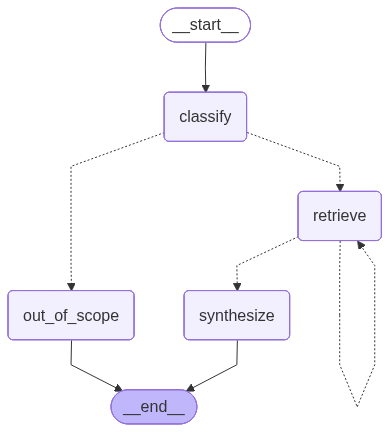

In [13]:
from IPython.display import Image, display

display(Image(qa_app.get_graph().draw_mermaid_png()))


## Βασικές αρχές που πρέπει να θυμάστε

1. **Κάθε node function** παίρνει ολόκληρο το state και επιστρέφει **μόνο τα πεδία που άλλαξε**.
2. **Η routing function** επιστρέφει **string** που αντιστοιχεί σε ένα node ή `END`.
3. **Το state είναι αμετάβλητο** — κάθε node φτιάχνει νέο dict, δεν τροποποιεί το state άμεσα.
4. **Τα loops** υλοποιούνται με conditional edge που επιστρέφει πίσω στον ίδιο κόμβο.
5. **Πάντα ορίζετε μέγιστο αριθμό επαναλήψεων** στο state για να αποφύγετε infinite loops.

---

Στο επόμενο notebook (`02_query_analyzer_agent.ipynb`) αντικαθιστούμε τους κανόνες `if/else` με πραγματικές κλήσεις στο Ollama.
